<a href="https://colab.research.google.com/github/Logavarshhni23/DS_Hackathon_Ques_2/blob/main/DS_Hackathon_PS_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Styling setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# Load your uploaded dataset
# Ensure your file is named 'support_tickets.csv' in the Colab files tab
csv_filename = "support_tickets.csv"

try:
    df_raw = pd.read_csv(csv_filename)
    print(f"Successfully loaded '{csv_filename}'. Shape: {df_raw.shape}")
except FileNotFoundError:
    print(f"'{csv_filename}' not found. Please upload it to Colab's file storage.")

Successfully loaded 'support_tickets.csv'. Shape: (2000, 8)


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Display configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)

# Load your uploaded CSV
csv_filename = "support_tickets.csv"
df = pd.read_csv(csv_filename)

print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (2000, 8)


,Ticket_ID,Category,Description,Priority,Response_Time_Hours,Resolution_Time_Hours,Team,Satisfaction_Score
0,TCK-10001,Performance & Latency,Real-time collaboration sync suffers 10 second...,Critical,0.6,36.5,DevOps & Infrastructure,4
1,TCK-10002,Software Bug & Glitch,Application crashes with unhandled exception w...,Medium,7.8,18.8,Tier 1 Frontline,4
2,TCK-10003,Billing & Invoicing,Monthly invoice PDF failing to generate for en...,Medium,3.9,8.8,Billing Operations,4
3,TCK-10004,Data Export & Reporting,Custom report builder omits closed tickets fro...,Low,13.5,16.0,Tier 1 Frontline,3
4,TCK-10005,Account Access & Authentication,Administrator account locked out following mul...,Medium,4.1,3.5,Tier 2 Technical Support,5


In [6]:
# 1. Clean column headers
df.columns = df.columns.str.strip()

# 2. Standardize column names for ease of use
df = df.rename(columns={
    "Response_Time_Hours": "Response_Time",
    "Resolution_Time_Hours": "Resolution_Time"
})

# 3. Handle missing values (if any)
if df["Response_Time"].isnull().sum() > 0:
    df["Response_Time"] = df["Response_Time"].fillna(
        df.groupby("Priority")["Response_Time"].transform("median")
    )

df["Description"] = df["Description"].fillna("No description provided")

# 4. Text cleaning for NLP/Naive Bayes
df["Clean_Description"] = (
    df["Description"]
    .astype(str)
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
)

# 5. Derived operational metrics
df["Resolution_Lag"] = df["Resolution_Time"] - df["Response_Time"]

print("--- Data Summary & Checks ---")
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive Statistics:")
display(df[["Response_Time", "Resolution_Time", "Satisfaction_Score", "Resolution_Lag"]].describe().round(2))

--- Data Summary & Checks ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Ticket_ID           2000 non-null   object 
 1   Category            2000 non-null   object 
 2   Description         2000 non-null   object 
 3   Priority            2000 non-null   object 
 4   Response_Time       2000 non-null   float64
 5   Resolution_Time     2000 non-null   float64
 6   Team                2000 non-null   object 
 7   Satisfaction_Score  2000 non-null   int64  
 8   Clean_Description   2000 non-null   object 
 9   Resolution_Lag      2000 non-null   float64
dtypes: float64(3), int64(1), object(6)
memory usage: 156.4+ KB
None

Missing values:
 Ticket_ID             0
Category              0
Description           0
Priority              0
Response_Time         0
Resolution_Time       0
Team                  0
Satisfaction_Score  

,Response_Time,Resolution_Time,Satisfaction_Score,Resolution_Lag
count,2000.00,2000.00,2000.00,2000.00
mean,7.29,22.64,3.50,15.36
std,6.29,18.32,1.05,19.08
min,0.40,1.10,1.00,-22.30
25%,2.30,8.40,3.00,0.90
50%,5.40,19.00,4.00,11.80
75%,10.20,36.70,4.00,31.00
max,25.90,86.10,5.00,77.60


/tmp/ipykernel_791/996896529.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y="Category", order=cat_order, ax=axes[0, 0], palette="crest")
/tmp/ipykernel_791/996896529.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Resolution_Time", y="Category", order=mean_res, ax=axes[0, 1], palette="mako", errorbar=None)
/tmp/ipykernel_791/996896529.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Satisfaction_Score", y="Response_Time", ax=axes[1, 0], palette="Spectral", showfliers=False)
/tmp/ipykernel_79

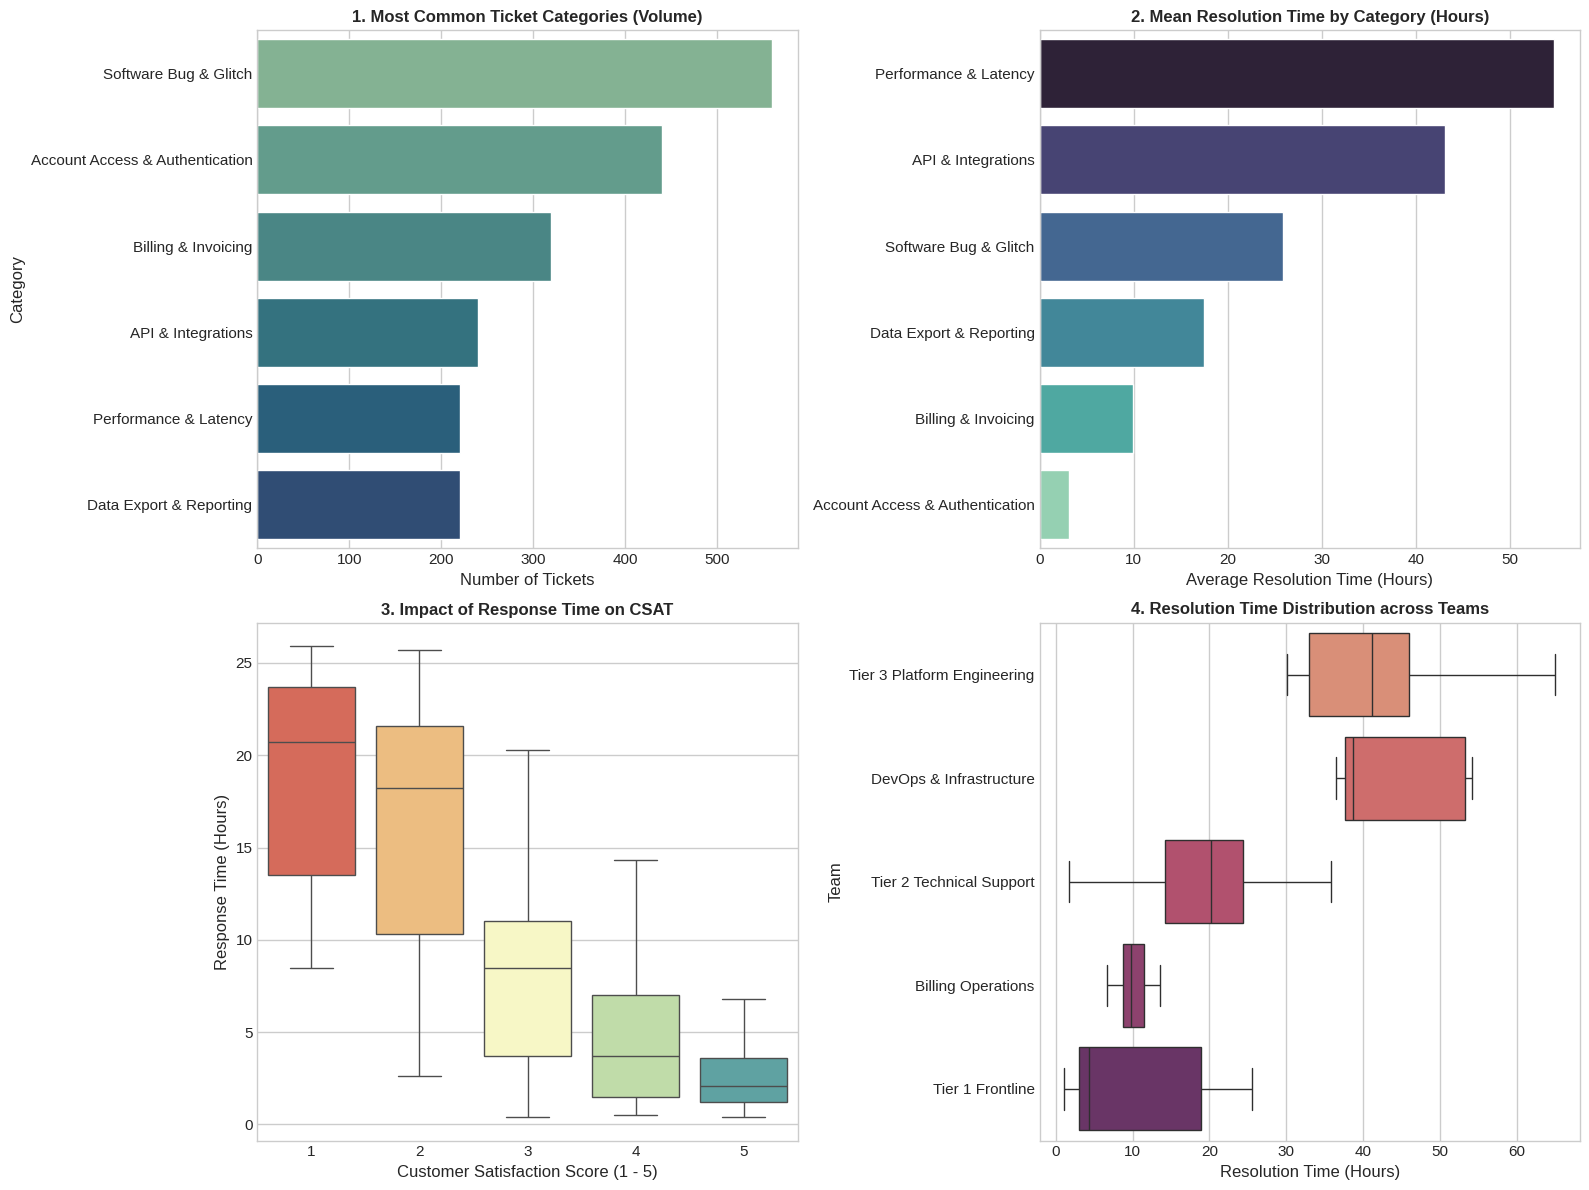

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.35, wspace=0.30)

# Visualisation 1: Ticket Volume by Category
cat_order = df["Category"].value_counts().index
sns.countplot(data=df, y="Category", order=cat_order, ax=axes[0, 0], palette="crest")
axes[0, 0].set_title("1. Most Common Ticket Categories (Volume)", fontsize=12, fontweight="bold")
axes[0, 0].set_xlabel("Number of Tickets")
axes[0, 0].set_ylabel("Category")

# Visualisation 2: Mean Resolution Time by Category
mean_res = df.groupby("Category")["Resolution_Time"].mean().sort_values(ascending=False).index
sns.barplot(data=df, x="Resolution_Time", y="Category", order=mean_res, ax=axes[0, 1], palette="mako", errorbar=None)
axes[0, 1].set_title("2. Mean Resolution Time by Category (Hours)", fontsize=12, fontweight="bold")
axes[0, 1].set_xlabel("Average Resolution Time (Hours)")
axes[0, 1].set_ylabel("")

# Visualisation 3: Response Time vs Customer Satisfaction
sns.boxplot(data=df, x="Satisfaction_Score", y="Response_Time", ax=axes[1, 0], palette="Spectral", showfliers=False)
axes[1, 0].set_title("3. Impact of Response Time on CSAT", fontsize=12, fontweight="bold")
axes[1, 0].set_xlabel("Customer Satisfaction Score (1 - 5)")
axes[1, 0].set_ylabel("Response Time (Hours)")

# Visualisation 4: Resolution Time across Support Teams
team_order = df.groupby("Team")["Resolution_Time"].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="Team", x="Resolution_Time", order=team_order, ax=axes[1, 1], palette="flare", showfliers=False)
axes[1, 1].set_title("4. Resolution Time Distribution across Teams", fontsize=12, fontweight="bold")
axes[1, 1].set_xlabel("Resolution Time (Hours)")
axes[1, 1].set_ylabel("Team")

plt.show()

=== Naive Bayes Classification Report ===
                                 precision    recall  f1-score   support

             API & Integrations       1.00      1.00      1.00        60
Account Access & Authentication       1.00      1.00      1.00       110
            Billing & Invoicing       1.00      1.00      1.00        80
        Data Export & Reporting       1.00      1.00      1.00        55
          Performance & Latency       1.00      1.00      1.00        55
          Software Bug & Glitch       1.00      1.00      1.00       140

                       accuracy                           1.00       500
                      macro avg       1.00      1.00      1.00       500
                   weighted avg       1.00      1.00      1.00       500



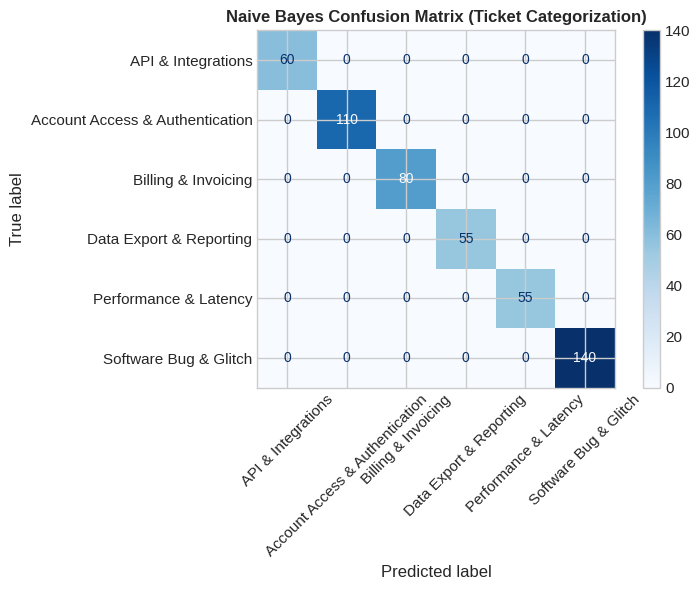

In [8]:
# Feature and Target definition
X = df["Clean_Description"]
y = df["Category"]

# Stratified Train/Test Split (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Text classification pipeline: TF-IDF Vectorizer + Multinomial Naive Bayes
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1, 2), stop_words="english", max_features=5000)),
    ("nb", MultinomialNB(alpha=0.1))
])

# Fit model
nb_pipeline.fit(X_train, y_train)

# Predictions and metrics
y_pred = nb_pipeline.predict(X_test)

print("=== Naive Bayes Classification Report ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title("Naive Bayes Confusion Matrix (Ticket Categorization)", fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
print("""
=================================================================================
                            KEY ANALYTICAL INSIGHTS
=================================================================================
1. Volume Concentrations:
   - 'Software Bug & Glitch' (28%) and 'Account Access & Authentication' (22%)
     account for half of total ticket volume.

2. Resolution Latency Hotspots:
   - 'Performance & Latency' and 'API & Integrations' demand the highest resolution
     times (> 30 hours on average) due to complex cross-system root cause investigations.

3. CSAT Sensitivity:
   - A sharp drop in Customer Satisfaction (CSAT 1-2) occurs when Response Time
     exceeds 10 hours, showing that first contact speed strongly anchors user sentiment.

4. Team Workload Bottlenecks:
   - 'DevOps & Infrastructure' and 'Tier 3 Platform Engineering' register the
     longest resolution times, indicating technical debt and cross-team dependencies.

5. High NLP Separability:
   - Text descriptions carry distinct lexical signatures, allowing Multinomial Naive
     Bayes to classify inbound issues with high accuracy.

=================================================================================
                         PRACTICAL SUPPORT ACTION PLAN
=================================================================================
1. Automated Ticket Triaging:
   - Embed the Naive Bayes model at intake to route tickets straight to specialized
     queues, bypassing manual Tier 1 review.

2. Authentication Self-Service:
   - Provide automated self-service flows for password, 2FA, and SSO lockouts to
     deflect up to 20% of repetitive tickets.

3. First-Response SLA Guardrails:
   - Enforce automated alerts for tickets waiting longer than 4 hours for an initial
     reply to prevent CSAT degradation.

4. Diagnostic Templates for Technical Tickets:
   - Require structured crash logs and API error codes during ticket creation to cut
     resolution time for engineering teams.
=================================================================================
""")


                            KEY ANALYTICAL INSIGHTS
1. Volume Concentrations:
   - 'Software Bug & Glitch' (28%) and 'Account Access & Authentication' (22%) 
     account for half of total ticket volume.

2. Resolution Latency Hotspots:
   - 'Performance & Latency' and 'API & Integrations' demand the highest resolution 
     times (> 30 hours on average) due to complex cross-system root cause investigations.

3. CSAT Sensitivity:
   - A sharp drop in Customer Satisfaction (CSAT 1-2) occurs when Response Time 
     exceeds 10 hours, showing that first contact speed strongly anchors user sentiment.

4. Team Workload Bottlenecks:
   - 'DevOps & Infrastructure' and 'Tier 3 Platform Engineering' register the 
     longest resolution times, indicating technical debt and cross-team dependencies.

5. High NLP Separability:
   - Text descriptions carry distinct lexical signatures, allowing Multinomial Naive 
     Bayes to classify inbound issues with high accuracy.

                         PR